In [23]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path

sys.path.append(str(Path.cwd().parent / 'scripts'))

from _tyndp_helpers import _extract_scenario_values, _extract_scenario_values_rowwise

In [33]:
eu27_countries = [
    "AT", "BE", "BG", "HR", "CZ", "DK", "EE", "FI", "FR", "DE", "GR", "HU", "IE",
    "IT", "LV", "LT", "LU", "NL", "PL", "PT", "RO", "SK", "SI", "ES", "SE",
]

In [22]:
valpath = Path.cwd().parent / 'data' / 'TYNDP_2024-Scenario-Report-Data-Figures_240522.xlsx'

In [19]:
dem = pd.read_csv(
    Path.cwd().parent / 'resources' / 'industrial_energy_demand_per_country_today.csv', header=[0,1], index_col=0
)
prod = pd.read_csv(
    Path.cwd().parent / 'resources' / 'industrial_production_per_country.csv', header=0, index_col=0
)

In [ ]:
def methane_industry_energetic(path):
    return _extract_scenario_values(path, sheet_name='8-', row_label='Industry')
def methane_industry_nonenergetic(path):
    return _extract_scenario_values(path, sheet_name='8-', row_label='Non-energy use')

In [28]:
dem

AL                                 \
            Alumina production Aluminium - primary production   
TWh/a                                                           
ammonia                    0.0                            0.0   
biomass                    0.0                            0.0   
electricity                0.0                            0.0   
gas                        0.0                            0.0   
heat                       0.0                            0.0   
hydrogen                   0.0                            0.0   
liquid                     0.0                            0.0   
other                      0.0                           -0.0   
solid                      0.0                            0.0   
waste                      0.0                            0.0   

                                                                    \
            Aluminium - secondary production Ammonia        Cement   
TWh/a                                                                
ammonia                                  0.0     0.0  0.000000e+00   
biomass                                  0.0     0.0  1.906630e-03   
electricity                              0.0     0.0  2.817006e-03   
gas                                      0.0     0.0  9.535426e-03   
heat                                     0.0     0.0  2.144612e-04   
hydrogen                                 0.0     0.0  0.000000e+00   
liquid                                   0.0     0.0  6.124493e-03   
other                                   -0.0     0.0 -1.255286e-18   
solid                                    0.0     0.0  3.262325e-03   
waste                                    0.0     0.0  4.798959e-03   

                                                          \
            Ceramics & other NMM  Chlorine  Electric arc   
TWh/a                                                      
ammonia             0.000000e+00  0.000000  0.000000e+00   
biomass             1.860580e-03  0.000000  1.745756e-04   
electricity         5.759261e-03  0.011160  6.071055e-02   
gas                 1.285101e-02  0.000000  3.241683e-02   
heat                4.057514e-04  0.000000  2.162600e-03   
hydrogen            0.000000e+00 -0.002905  0.000000e+00   
liquid              5.542503e-03  0.000000  2.096589e-03   
other              -6.306161e-19  0.000000 -2.724209e-18   
solid               3.401920e-03  0.000000  1.406566e-03   
waste               3.604022e-03  0.000000  5.335114e-06   

                                                          ...              XK  \
            Food, beverages and tobacco Glass production  ... Other chemicals   
TWh/a                                                     ...                   
ammonia                    0.000000e+00     0.000000e+00  ...    0.000000e+00   
biomass                    2.959699e-02     3.763335e-05  ...    3.283821e-05   
electricity                2.006112e-01     3.650089e-03  ...    9.666255e-04   
gas                        2.649908e-01     6.422005e-03  ...    1.323223e-03   
heat                       2.977809e-02     0.000000e+00  ...    5.014533e-04   
hydrogen                   0.000000e+00     0.000000e+00  ...    0.000000e+00   
liquid                     3.005989e-02     4.658897e-04  ...    4.316407e-04   
other                      2.431179e-17    -9.447981e-20  ...   -2.187968e-19   
solid                      2.391242e-02     1.656717e-03  ...    2.662675e-04   
waste                      1.536753e-04     0.000000e+00  ...    2.949609e-05   

                                                               \
            Other industrial sectors Other non-ferrous metals   
TWh/a                                                           
ammonia                 0.000000e+00                      0.0   
biomass                 1.848777e-02                      0.0   
electricity             1.937139e-01                      0.0   
gas                     9.114439e-02          

In [35]:
idx = pd.IndexSlice

# EU27 demand today
methane_today = dem.loc[:, idx[eu27_countries]].sum(axis=1).loc['gas']
methane_today

1157.2785027726861

In [36]:
heat_gas_demand = methane_industry_energetic(valpath)
process_gas_demand = methane_industry_nonenergetic(valpath)

In [114]:
heat_gas_demand

{'National Trends': {2030: 888.188982683603, 2040: 595.9978468590181},
 'Distributed Energy': {2040: 477.3971818688508, 2050: 248.66383725068562},
 'Global Ambition': {2040: 553.2439756265355, 2050: 306.10857628850994},
 'Reference': {2019: 1034.0050852378477}}

In [120]:
phaseout_potential_2030 = 1 - heat_gas_demand['National Trends'][2030] / heat_gas_demand['Reference'][2019]
phaseout_potential_2030

0.1410206822345591

In [123]:
phaseout_potential_2040 = 1 - heat_gas_demand['National Trends'][2040] / heat_gas_demand['Reference'][2019]
phaseout_potential_2035 = (phaseout_potential_2030 + phaseout_potential_2040) / 2
phaseout_potential_2035

0.28231163911480184

In [122]:
prod.head()

,Electric arc,Integrated steelworks,Other chemicals,Pharmaceutical products etc.,Cement,Ceramics & other NMM,Glass production,Pulp production,Paper production,Printing and media reproduction,...,Other non-ferrous metals,Transport equipment,Machinery equipment,Textiles and leather,Wood and wood products,Other industrial sectors,Ammonia,HVC,Chlorine,Methanol
kton/a,,,,,,,,,,,,,,,,,,,,,
AL,72.67,98.64,7.42,2.84,33.15,59.54,6.75,11.68,26.39,3.03,...,0.00,0.00,0.00,273.17,4.09,1118.77,0.00,16.80,3.10,0.48
AT,709.23,6714.29,476.35,197.38,4516.95,9961.66,765.62,2090.27,4984.71,235.83,...,417.93,4533.23,17870.55,1157.96,2391.98,28333.84,552.50,879.38,162.01,25.37
BA,597.14,810.50,9.83,3.77,899.84,1616.27,183.26,30.16,68.16,7.82,...,0.00,226.13,1130.02,379.98,91.83,1244.88,0.00,22.26,4.10,0.64
BE,2520.00,5239.54,1526.66,365.53,5834.21,13772.26,1399.07,514.98,1935.11,612.52,...,1861.50,4224.66,9654.64,3005.12,1003.79,23760.91,1056.43,4207.56,775.16,121.37
BG,565.90,0.00,525.90,90.36,2371.46,4577.70,612.27,238.79,363.97,36.92,...,448.36,629.06,4656.30,1106.23,292.34,8597.73,279.29,374.98,69.08,10.82


In [6]:
dem.loc['gas'].loc['DE'].sort_values()

Ammonia                              0.000000
Chlorine                             0.000000
Printing and media reproduction      0.333849
Aluminium - primary production       0.469768
Aluminium - secondary production     0.627377
Wood and wood products               1.265818
Pulp production                      1.660246
Textiles and leather                 2.462652
Alumina production                   3.917683
Methanol                             4.450550
Other non-ferrous metals             4.836333
Electric arc                         5.142603
Glass production                     5.677610
Pharmaceutical products etc.         5.919894
Cement                               9.771302
Transport equipment                 10.484600
Ceramics & other NMM                13.738040
Other chemicals                     14.036268
Other industrial sectors            16.687439
Paper production                    19.808504
Machinery equipment                 20.604482
Food, beverages and tobacco       

In [84]:
ratios = pd.read_csv(
    Path.cwd().parent / 'resources' / 'industry_sector_ratios_endogenous.csv',
    index_col=0,
    header=[0,1]
)
exo_demands = pd.read_csv(
    Path.cwd().parent / 'resources' / 'industrial_energy_demand_per_country_today.csv',
    index_col=0,
    header=[0,1]
)
exo_demands = exo_demands.loc['gas'].unstack()

In [87]:
exo_demands.head()

,Alumina production,Aluminium - primary production,Aluminium - secondary production,Ammonia,Cement,Ceramics & other NMM,Chlorine,Electric arc,"Food, beverages and tobacco",Glass production,...,Other chemicals,Other industrial sectors,Other non-ferrous metals,Paper production,Pharmaceutical products etc.,Printing and media reproduction,Pulp production,Textiles and leather,Transport equipment,Wood and wood products
AL,0.0,0.0,0.000000,0.0,0.009535,0.012851,0.0,0.032417,0.264991,0.006422,...,0.014654,0.072054,0.000000,0.017800,0.005968,0.000638,0.003891,0.083259,0.000000,0.000680
AT,0.0,0.0,0.460916,0.0,1.471297,2.051738,0.0,0.330592,3.357337,0.650172,...,1.075359,2.471738,0.931077,4.698426,0.497876,0.064402,1.861490,0.433085,0.441671,0.638560
BA,0.0,0.0,0.000000,0.0,0.258834,0.348853,0.0,0.266374,0.321007,0.174355,...,0.019414,0.080176,0.000000,0.045973,0.007923,0.001647,0.010048,0.115814,0.021147,0.015267
BE,0.0,0.0,0.000000,0.0,1.906040,2.628812,0.0,0.946281,11.012726,1.301972,...,2.732476,2.078834,1.354201,0.978412,0.694369,0.255001,0.255686,0.938218,0.428223,0.251160
BG,0.0,0.0,0.006977,0.0,1.114581,1.155062,0.0,0.600355,0.977128,0.755451,...,0.904209,0.650057,0.554394,0.232611,0.281698,0.032237,0.210804,0.183480,0.063016,0.086220


In [ ]:
methane_demand_distribution = ratios.T['methane']

In [78]:
gasdems = ratios.T['methane'].unstack()
gasdems = gasdems.loc[:, gasdems.sum() > 0]
proc_gasdems = gasdems.mul(prod[gasdems.columns] * 1e3) / 1e6

In [79]:
total_gasdems = exo_demands.loc[:, gasdems.columns]

In [80]:
total_gasdems.head()

,Electric arc,Integrated steelworks,Methanol,Other chemicals
AL,0.032417,0.121874,0.004920,0.014654
AT,0.330592,7.633445,0.260043,1.075359
BA,0.266374,2.309733,0.006560,0.019414
BE,0.946281,8.606164,1.244043,2.732476
BG,0.600355,0.000000,0.110905,0.904209


In [81]:
proc_gasdems.head()

,Electric arc,Integrated steelworks,Methanol,Other chemicals
AL,0.032417,0.121874,0.004920,0.014654
AT,0.330592,7.633445,0.260043,1.075359
BA,0.266374,2.309733,0.006560,0.019414
BE,0.946281,8.606164,1.244042,2.732476
BG,0.600355,0.000000,0.110905,0.904209


In [90]:
heat_only_gas_demand = exo_demands.copy()
heat_only_gas_demand.loc[:, proc_gasdems.columns] -= proc_gasdems

In [91]:
heat_only_gas_demand.head()

,Alumina production,Aluminium - primary production,Aluminium - secondary production,Ammonia,Cement,Ceramics & other NMM,Chlorine,Electric arc,"Food, beverages and tobacco",Glass production,...,Other chemicals,Other industrial sectors,Other non-ferrous metals,Paper production,Pharmaceutical products etc.,Printing and media reproduction,Pulp production,Textiles and leather,Transport equipment,Wood and wood products
AL,0.0,0.0,0.000000,0.0,0.009535,0.012851,0.0,6.938894e-18,0.264991,0.006422,...,1.734723e-18,0.072054,0.000000,0.017800,0.005968,0.000638,0.003891,0.083259,0.000000,0.000680
AT,0.0,0.0,0.460916,0.0,1.471297,2.051738,0.0,0.000000e+00,3.357337,0.650172,...,0.000000e+00,2.471738,0.931077,4.698426,0.497876,0.064402,1.861490,0.433085,0.441671,0.638560
BA,0.0,0.0,0.000000,0.0,0.258834,0.348853,0.0,0.000000e+00,0.321007,0.174355,...,0.000000e+00,0.080176,0.000000,0.045973,0.007923,0.001647,0.010048,0.115814,0.021147,0.015267
BE,0.0,0.0,0.000000,0.0,1.906040,2.628812,0.0,1.110223e-16,11.012726,1.301972,...,0.000000e+00,2.078834,1.354201,0.978412,0.694369,0.255001,0.255686,0.938218,0.428223,0.251160
BG,0.0,0.0,0.006977,0.0,1.114581,1.155062,0.0,0.000000e+00,0.977128,0.755451,...,-2.220446e-16,0.650057,0.554394,0.232611,0.281698,0.032237,0.210804,0.183480,0.063016,0.086220


In [104]:
total_heat_demands = pd.concat([
    ratios.loc[band].unstack().mul(prod.mul(1e3).div(1e6)).stack().rename(band)
    for band in ['heat<100', 'heat100-200', 'heat200-500', 'heat>500']], axis=1
).T

In [109]:
total_heat_demands.loc[:, 'DE']

,Alumina production,Aluminium - primary production,Aluminium - secondary production,Ammonia,Cement,Ceramics & other NMM,Chlorine,Electric arc,"Food, beverages and tobacco",Glass production,...,Other chemicals,Other industrial sectors,Other non-ferrous metals,Paper production,Pharmaceutical products etc.,Printing and media reproduction,Pulp production,Textiles and leather,Transport equipment,Wood and wood products
heat<100,0.000000,0.009663,0.181032,0.0,0.370790,4.997545,0.0,0.056219,19.252673,0.113889,...,7.216617,2.055079,0.098249,18.180862,2.611081,0.176688,0.178941,1.854215,3.497168,9.974624
heat100-200,0.000000,0.043483,0.000000,0.0,0.000000,1.984319,0.0,0.000000,12.611719,1.081946,...,0.000000,13.358011,0.000000,17.467887,5.222161,0.169759,2.594651,0.529776,8.393204,5.370951
heat200-500,0.000000,0.014494,0.193963,0.0,1.853950,1.616853,0.0,0.000000,2.863530,1.385650,...,0.000000,5.137697,1.925682,0.000000,0.870360,0.000000,0.149118,0.264888,2.098301,0.000000
heat>500,4.197253,0.415509,0.271548,0.0,16.314758,13.449277,0.0,0.000000,1.829004,3.112968,...,0.000000,0.000000,2.888523,0.000000,8.703602,0.000000,0.059647,0.000000,0.000000,0.000000


In [113]:
heat_only_gas_demand.loc[['DE']]

,Alumina production,Aluminium - primary production,Aluminium - secondary production,Ammonia,Cement,Ceramics & other NMM,Chlorine,Electric arc,"Food, beverages and tobacco",Glass production,...,Other chemicals,Other industrial sectors,Other non-ferrous metals,Paper production,Pharmaceutical products etc.,Printing and media reproduction,Pulp production,Textiles and leather,Transport equipment,Wood and wood products
DE,3.917683,0.469768,0.627377,0.0,9.771302,13.73804,0.0,1.776357e-15,32.387098,5.67761,...,0.0,16.687439,4.836333,19.808504,5.919894,0.333849,1.660246,2.462652,10.4846,1.265818


In [58]:
ratios

AL                                 \
            Alumina production Aluminium - primary production   
MWh/t                                                           
ammonia               0.000000                       0.000000   
biomass               0.000000                       0.000000   
coke                  0.170908                       0.055130   
elec                  0.930804                      14.022713   
heat100-200           0.000000                       0.112102   
heat200-500           0.000000                       0.037367   
heat<100              0.000000                       0.024911   
heat>500              2.543307                       1.071193   
hydrogen              0.000000                       0.000000   
methane               0.000000                       0.000000   
naphtha               0.107037                       0.094618   

                                                                \
            Aluminium - secondary production Ammonia    Cement   
MWh/t                                                            
ammonia                             0.000000   5.166  0.000000   
biomass                             0.000000   0.000  0.000000   
coke                                0.022335   0.000  0.098411   
elec                                0.736414   0.000  0.084978   
heat100-200                         0.000000   0.000  0.000000   
heat200-500                         0.315914   0.000  0.049639   
heat<100                            0.294853   0.000  0.009928   
heat>500                            0.442279   0.000  0.436827   
hydrogen                            0.000000   0.000  0.000000   
methane                             0.000000   0.000  0.000000   
naphtha                             0.077851   0.000  0.184751   

                                                        \
            Ceramics & other NMM Chlorine Electric arc   
MWh/t                                                    
ammonia                 0.000000   0.0000     0.000000   
biomass                 0.000000   0.0000     0.002476   
coke                    0.057137   0.0000     0.019356   
elec                    0.096729   3.6000     0.835428   
heat100-200             0.028299   0.0000     0.000000   
heat200-500             0.023058   0.0000     0.000000   
heat<100                0.071272   0.0000     0.029759   
heat>500                0.191804   0.0000     0.000000   
hydrogen                0.000000  -0.9372     0.000000   
methane                 0.000000   0.0000     0.446083   
naphtha                 0.093089   0.0000     0.028851   

                                                          ...              XK  \
            Food, beverages and tobacco Glass production  ... Other chemicals   
MWh/t                                                     ...                   
ammonia                        0.000000         0.000000  ...        0.000000   
biomass                        0.000000         0.000000  ...        0.093036   
coke                           0.055553         0.245440  ...        0.397414   
elec                           0.466061         0.540754  ...        1.442725   
heat100-200                    0.260104         0.181827  ...        0.000000   
heat200-500                    0.059057         0.232866  ...        0.000000   
heat<100                       0.397067         0.019140  ...        0.748438   
heat>500                       0.037721         0.523151  ...        0.000000   
hydrogen                       0.000000         0.000000  ...        0.000000   
methane                        0.000000         0.000000  ...        1.974960   
naphtha                        0.069835         0.069021  ...        0.644240   

                                                               \
            Other industrial sectors Other non-ferrous metals   
MWh/t                                                           
ammonia                     0.000000             

In [51]:
gasdems = gasdems.div(gasdems.sum(axis=1), axis=0)
gasdems

,Electric arc,Integrated steelworks,Methanol,Other chemicals
AL,0.032077,0.088846,0.737061,0.142016
AT,0.033034,0.080571,0.726408,0.159987
BA,0.028741,0.183609,0.660404,0.127246
BE,0.026712,0.116841,0.729128,0.127319
BG,0.072427,0.110425,0.699768,0.117380
CH,0.032077,0.088846,0.737061,0.142016
CZ,0.028394,0.138967,0.729927,0.102712
DE,0.029389,0.139535,0.697380,0.133696
DK,0.070478,0.108187,0.685585,0.135750
EE,0.042346,0.000000,0.886123,0.071531


In [38]:
methane_demand_distribution / methane_demand_distribution.sum()

Alumina production                  0.000000
Aluminium - primary production      0.000000
Aluminium - secondary production    0.000000
Ammonia                             0.000000
Cement                              0.000000
Ceramics & other NMM                0.000000
Chlorine                            0.000000
Electric arc                        0.029389
Food, beverages and tobacco         0.000000
Glass production                    0.000000
HVC                                 0.000000
Integrated steelworks               0.139535
Machinery equipment                 0.000000
Methanol                            0.697380
Other chemicals                     0.133696
Other industrial sectors            0.000000
Other non-ferrous metals            0.000000
Paper production                    0.000000
Pharmaceutical products etc.        0.000000
Printing and media reproduction     0.000000
Pulp production                     0.000000
Textiles and leather                0.000000
Transport 

##### Method-certain part

In [124]:
idx = pd.IndexSlice

# maps processes to temperature bands distributions from Fleiter et al. 2025
process_temperature_band_mapper = {
    "Aluminium - secondary production": idx[
        "Non-ferrous metals", "NE metals", ["Aluminium, secondary"]
    ],
    "Aluminium - primary production": idx[
        "Non-ferrous metals", "NE metals", ["Aluminium, primary"]
    ],
    "Other non-ferrous metals": idx[
        "Non-ferrous metals",
        "NE metals",
        [
            "Copper, primary",
            "Copper, secondary",
            "Copper further treatment",
            "Zinc, primary",
            "Zinc, secondary",
        ],
    ],
    "HVC": idx[
        :,
        :,
        [
            "Adipic acid",
            "Calcium carbide",
            "Carbon black",
            "Nitric acid",
            "Soda ash",
            "TDI",
            "Titanium dioxide",
        ],
    ],
    "Cement": idx["Non-metallic mineral products", "Clinker", :],
    "Ceramics & other NMM": idx["Non-metallic mineral products", "Ceramics", :],
    "Glass production": idx["Non-metallic mineral products", "Glass", :],
    "Pulp production": idx[
        "Paper and printing", "Paper products", ["Paper", "Paper Electrical"]
    ],
    "Paper production": idx[
        "Paper and printing", "Paper products", ["Chemical pulp", "Mechanical pulp"]
    ],
    "Printing and media reproduction": idx[
        "Paper and printing", "Paper products", ["Chemical pulp", "Mechanical pulp"]
    ],
    "Food, beverages and tobacco": idx["Food, drink and tobacco", :, :],
}

backup_temperature_band_shares = {
    # from JRC IDEES EU26 Industry
    "Alumina production": {
        "heat<100": 0.0,
        "heat100-200": 0.0,
        "heat200-500": 0.0,
        "heat>500": 1.0,
    },
    "Pharmaceutical products etc.": {
        "heat<100": 0.3,
        "heat100-200": 0.6,
        "heat200-500": 0.1,
        "heat>500": 1.0,
    },
    # from https://energyinnovation.org/data-explorer/overcoming-all-barriers-to-industrial-electrification
    "Other industrial sectors": {
        "heat<100": 0.1,
        "heat100-200": 0.65,
        "heat200-500": 0.25,
        "heat>500": 0.0,
    },
    "Transport equipment": {
        "heat<100": 0.25,
        "heat100-200": 0.6,
        "heat200-500": 0.15,
        "heat>500": 0.0,
    },
    "Machinery equipment": {
        "heat<100": 0.25,
        "heat100-200": 0.6,
        "heat200-500": 0.15,
        "heat>500": 0.0,
    },
    # from https://www.fpl.fs.usda.gov/documents/fplgtr/fplgtr118.pdf
    "Wood and wood products": {
        "heat<100": 0.65,
        "heat100-200": 0.35,
        "heat200-500": 0.0,
        "heat>500": 0.0,
    },
    # from https://www.ifc.org/content/dam/ifc/doc/2000/2007-textiles-manufacturing-ehs-guidelines-en.pdf
    "Textiles and leather": {
        "heat<100": 0.7,
        "heat100-200": 0.2,
        "heat200-500": 0.1,
        "heat>500": 0.0,
    },
}


In [ ]:
def take_cumulative_amount(obj, y, *, from_start=True, clip_negative=True):
    """
    Take the first `y` of cumulative mass from a non-negative Series (or each column of a DataFrame),
    either from the start (left) or from the end (right), returning an object of the same shape.

    `y` can be:
      - float/int (applied to the whole Series, or to every column of a DataFrame), or
      - pd.Series indexed by DataFrame columns (per-column y).

    Example:
        s = pd.Series([1,2,3])
        take_cumulative_amount(s, 2.5, from_start=True)  -> [1, 1.5, 0]
        take_cumulative_amount(s, 2.5, from_start=False) -> [0, 0, 2.5]
    """

    def _take_array(a: np.ndarray, y_val: float) -> np.ndarray:
        a = a.astype(float, copy=True)
        if clip_negative:
            a = np.maximum(a, 0.0)

        if not np.isfinite(y_val):
            raise ValueError("y must be a finite number (or a Series of finite numbers).")
        if y_val <= 0.0:
            return np.zeros_like(a)

        total = float(a.sum())
        if y_val >= total:
            return a

        if from_start:
            remaining_before = y_val - np.cumsum(np.r_[0.0, a[:-1]])
            return np.clip(remaining_before, 0.0, a)
        else:
            ar = a[::-1]
            remaining_before = y_val - np.cumsum(np.r_[0.0, ar[:-1]])
            outr = np.clip(remaining_before, 0.0, ar)
            return outr[::-1]

    # --- Series input ---
    if isinstance(obj, pd.Series):
        y_val = float(y)  # must be scalar for Series input
        out = _take_array(obj.to_numpy(), y_val)
        return pd.Series(out, index=obj.index, name=obj.name)

    # --- DataFrame input ---
    if isinstance(obj, pd.DataFrame):
        if isinstance(y, pd.Series):
            # align to columns; require all columns present
            y_aligned = y.reindex(obj.columns)
            missing = y_aligned.isna()
            if missing.any():
                missing_cols = list(obj.columns[missing.to_numpy()])
                raise ValueError(
                    f"y is missing values for columns: {missing_cols}. "
                    "Provide a y Series indexed by all DataFrame columns."
                )
            y_map = y_aligned.astype(float)
        else:
            y_scalar = float(y)
            if not np.isfinite(y_scalar):
                raise ValueError("y must be a finite number (or a Series of finite numbers).")
            y_map = pd.Series(y_scalar, index=obj.columns, dtype=float)

        out = obj.copy()
        for col in obj.columns:
            out[col] = _take_array(obj[col].to_numpy(), float(y_map.loc[col]))
        return out

    raise TypeError("obj must be a pandas Series or DataFrame.")

In [161]:
# in TWh/a
demand = pd.read_csv(
    Path.cwd().parent / 'resources' / 'industrial_energy_demand_per_country_today.csv',
    header=[0, 1],
    index_col=0,
)

# in Mt/a
production = (
    pd.read_csv(
        Path.cwd().parent / 'resources' / 'industrial_production_per_country.csv',
        index_col=0)
    / 1e3
).stack()
production.index.names = [None, None]

today_sector_ratios = demand.div(production, axis=1).replace([np.inf, -np.inf], 0)
today_sector_ratios.index.name = 'MWh/t'

today_sector_ratios.dropna(how="all", axis=1, inplace=True)

rename = {
    "waste": "biomass",
    "electricity": "elec",
    "solid": "coke",
    "gas": "methane",
    "other": "biomass",
    "liquid": "naphtha",
}
today_sector_ratios = today_sector_ratios.rename(rename).groupby(level=0).sum()

process_temperature_bands = pd.read_excel(
    Path.cwd().parent / 'data' / 'ente202300981-sup-0001-suppdata-s1.xlsx',
    sheet_name="Industry_ESC_FEC",
    index_col=[0, 1, 2],
    header=[0, 1],
)
process_temperature_bands.columns = process_temperature_bands.columns.droplevel(0)
process_temperature_bands.rename(
    columns={
        "<\xa0100\xa0°C": "heat<100",
        "<\xa0100–200\xa0°C": "heat100-200",
        "200–500\xa0°C": "heat200-500",
        "500–1000\xa0°C": "heat500-1000",
        ">\xa01000\xa0°C": "heat>1000",
    },
    inplace=True,
)
process_temperature_bands.loc[:, "heat>500"] = (
    process_temperature_bands.loc[:, "heat500-1000"]
    + process_temperature_bands.loc[:, "heat>1000"]
)
process_temperature_bands = process_temperature_bands[
    ["heat<100", "heat100-200", "heat200-500", "heat>500"]
]

heat_carriers = ["heat", "biomass", "methane"]
bands = ["heat<100", "heat100-200", "heat200-500", "heat>500"]

skip_processes = [
    'Electric arc',
    'Integrated steelworks',
    'Methanol',
    'Other chemicals',
]

/tmp/ipykernel_129564/1290930415.py:49: PerformanceWarning: indexing past lexsort depth may impact performance.
  process_temperature_bands.loc[:, "heat>500"] = (


In [153]:
phaseout = 0.2

endogenous_sector_ratios = today_sector_ratios.copy()

endogenous_sector_ratios = endogenous_sector_ratios.reindex(
    endogenous_sector_ratios.index.union(bands)
).replace(np.nan, 0)

countries = ['DE', 'IT', 'FR']

for process, key in process_temperature_band_mapper.items():

    print('beginning')
    print(endogenous_sector_ratios.loc[bands, idx[countries, process]])
    print(endogenous_sector_ratios.loc[['methane', 'biomass', 'heat'], idx[countries, process]])

    as_fuels = endogenous_sector_ratios.loc[heat_carriers, idx[:, process]]

    as_heat = pd.DataFrame(
        np.outer(
            process_temperature_bands.loc[key].mean().values, as_fuels.sum().values
        ),
        index=bands,
        columns=as_fuels.sum().index,
    )

    # print(process)
    # print(as_heat.loc[:, countries])
    # print(as_heat.loc[:, countries].sum())
    # print(as_fuels.loc[:, countries])
    # print(as_fuels.loc[:, countries].sum())

    gas_share = as_fuels.loc[['methane']]

    gas_heat_share = take_cumulative_amount(
        as_heat,
        as_fuels.loc['methane'],
        from_start=False
        )

    decarbonise_heat_share = take_cumulative_amount(
        gas_heat_share,
        as_fuels.loc['methane'] * phaseout,
        from_start=True
        )

    # print(gas_share.loc[:, countries])
    # print(gas_heat_share.loc[:, countries])
    # print(decarbonise_heat_share.loc[:, countries])

    endogenous_sector_ratios.loc[bands, idx[:, process]] = decarbonise_heat_share
    endogenous_sector_ratios.loc[['methane'], idx[:, process]] *= 1 - phaseout

    print('final')
    print(endogenous_sector_ratios.loc[bands, idx[countries, process]])
    print(endogenous_sector_ratios.loc[['methane', 'biomass', 'heat'], idx[countries, process]])



    break

beginning
                                          DE                               IT  \
            Aluminium - secondary production Aluminium - secondary production   
MWh/t                                                                           
heat<100                                 0.0                              0.0   
heat100-200                              0.0                              0.0   
heat200-500                              0.0                              0.0   
heat>500                                 0.0                              0.0   

                                          FR  
            Aluminium - secondary production  
MWh/t                                         
heat<100                                 0.0  
heat100-200                              0.0  
heat200-500                              0.0  
heat>500                                 0.0  
                                      DE                               IT  \
        Aluminiu

In [155]:
skip_processes

['Electric arc', 'Integrated Steelworks', 'Methanol', 'Other Chemicals']

In [160]:
dem.columns.unique(1)

Index(['Alumina production', 'Aluminium - primary production',
       'Aluminium - secondary production', 'Ammonia', 'Cement',
       'Ceramics & other NMM', 'Chlorine', 'Electric arc',
       'Food, beverages and tobacco', 'Glass production', 'HVC',
       'Integrated steelworks', 'Machinery equipment', 'Methanol',
       'Other chemicals', 'Other industrial sectors',
       'Other non-ferrous metals', 'Paper production',
       'Pharmaceutical products etc.', 'Printing and media reproduction',
       'Pulp production', 'Textiles and leather', 'Transport equipment',
       'Wood and wood products'],
      dtype='object')

In [169]:
dem.loc[:, eu27_countries].T.groupby(level=1).sum().T[skip_processes].sum(axis=1).loc['gas']

253.2772075279041

In [170]:
dem.loc[:, eu27_countries].T.groupby(level=1).sum().T.drop(columns=skip_processes).sum(axis=1).loc['gas']

904.0012952447802

In [164]:
methane_industry_energetic(valpath)

{'National Trends': {2030: 888.188982683603, 2040: 595.9978468590181},
 'Distributed Energy': {2040: 477.3971818688508, 2050: 248.66383725068562},
 'Global Ambition': {2040: 553.2439756265355, 2050: 306.10857628850994},
 'Reference': {2019: 1034.0050852378477}}

In [165]:
methane_industry_nonenergetic(valpath)

{'National Trends': {2030: 166.3819071209875, 2040: 114.02911502002678},
 'Distributed Energy': {2040: 82.23988146608082, 2050: 37.708800167460865},
 'Global Ambition': {2040: 123.60639235067094, 2050: 74.81858845593675},
 'Reference': {2019: 177.51493725042747}}

In [171]:
253 + 904

1157

In [172]:
1034 + 178

1212

#### Validation

In [179]:
from tqdm import tqdm

# years = range(2025, 2036)
years = [2025, 2028, 2030, 2032, 2035]
vals = []

for y in tqdm(years):

    dems = pd.read_csv(
        Path.cwd().parent / 'resources' / f'industrial_energy_demand_base_s_50_{y}.csv',
        index_col=0, header=[0,1]
    ).sum()
    vals.append(dems.rename(y))

df = pd.concat(vals, axis=1)
df

100%|██████████| 5/5 [00:00<00:00, 427.24it/s]


2025     2028     2030  \
exogenous  electricity                      1070.67  1141.63  1188.39   
           coal                               14.14    12.85    11.96   
           coke                              354.79   301.51   268.79   
           solid biomass                     367.20   403.01   426.95   
           methane                          1175.32  1071.39  1004.03   
           hydrogen                           -8.79    -1.94     2.15   
           low-temperature heat              185.60   171.38   162.18   
           naphtha                           896.13   834.24   793.36   
           ammonia                            87.30    87.30    87.30   
           methanol                            8.74     8.74     8.74   
           process emission                  190.27   183.95   179.88   
           process emission from feedstock    22.87    21.73    20.97   
           current electricity              1046.05  1046.05  1046.05   
endogenous low-temperature heat              191.94   224.09   241.33   
           ammonia                            87.30    87.30    87.30   
           solid biomass                     347.16   346.89   346.68   
           coke                              372.54   348.15   332.50   
           electricity                      1035.84  1044.56  1050.20   
           heat100-200                         0.00    31.09    53.78   
           heat200-500                         0.00     2.92     5.36   
           heat>500                            0.00     9.85    17.18   
           hydrogen                           -9.18    -2.99     0.72   
           methane                          1219.94  1114.74  1046.23   
           naphtha                           912.32   879.00   856.75   
           coal                                0.00     0.00     0.00   
           methanol                            0.00     0.00     0.00   
           process emission                    0.00     0.15     0.24   
           process emission from feedstock     0.00     0.00     0.00   
           current electricity              1046.05  1046.05  1046.05   

                                               2032     2035  
exogenous  electricity                      1263.14  1373.61  
           coal                               10.83     9.23  
           coke                              222.32   160.74  
           solid biomass                     466.97   527.05  
           methane                           900.82   751.84  
           hydrogen                            9.44    19.20  
           low-temperature heat              148.10   127.74  
           naphtha                           737.27   654.26  
           ammonia                            87.30    87.30  
           methanol                            8.74     8.74  
           process emission                  174.62   167.13  
           process emission from feedstock    20.09    18.80  
           current electricity              1046.05  1046.05  
endogenous low-temperature heat              253.85   267.76  
           ammonia                            87.30    87.30  
           solid biomass                     346.47   346.14  
           coke                              312.03   283.15  
           electricity                      1056.93  1066.53  
           heat100-200                        78.34   115.11  
           heat200-500                         8.53    14.01  
           heat>500                           24.88    38.84  
           hydrogen                            7.41    16.32  
           methane                           974.75   870.77  
           naphtha                           831.30   793.13  
           coal                                0.00     0.00  
           methanol                            0.00     0.00  
           process emission                    0.41     0.60  
           process emission from feedstock     0.00     0.00  
           current electricit

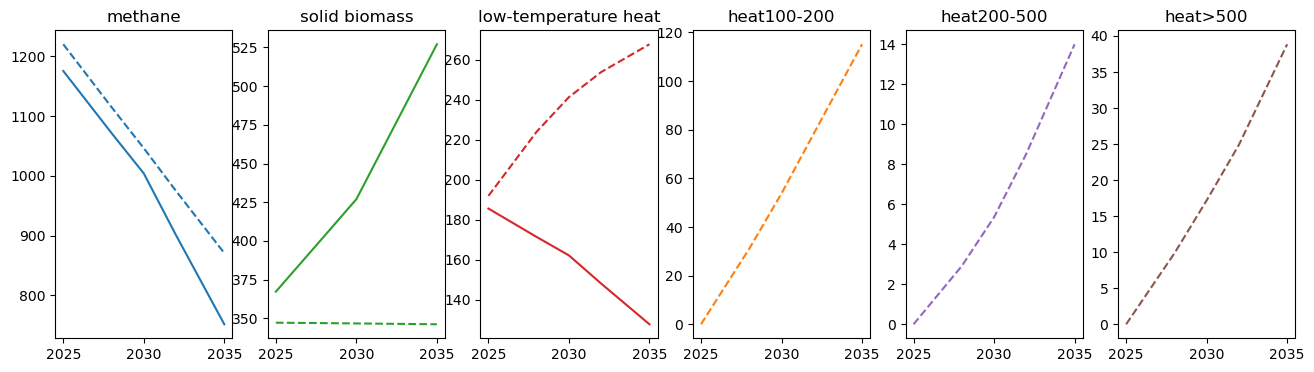

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 6, figsize=(16, 4))

colors = ['tab:blue', 'tab:green', 'tab:red', 'tab:orange', 'tab:purple', 'tab:brown']

for i, carrier in enumerate(['methane', 'solid biomass', 'low-temperature heat', 'heat100-200', 'heat200-500', 'heat>500']):

    ax = axs[i]
    c = colors[i]

    df.loc[('endogenous', carrier)].plot(ax=ax, color=c, linestyle='--')

    try:
        df.loc[('exogenous', carrier)].plot(ax=ax, color=c, linestyle='-')
    except KeyError:
        pass

    ax.set_title(carrier)

In [ ]:
k